In [8]:
%load_ext autoreload
%autoreload 2

import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy import constants
from collections import defaultdict
from scipy.interpolate import make_interp_spline
import ozy

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
directory = '/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/'
ozy_files = []
for filename in glob.glob(os.path.join(directory, '*.hdf5')):
    ozy_files.append(filename)

ozy_file = ozy_files[0]


In [10]:
%store -r chosen_gals_numbers

gal_number = chosen_gals_numbers[0]



In [28]:
directory = '/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/'

star_name = '*star*_' + str(gal_number) + '.hdf5'
dm_name = '*dm*_' + str(gal_number) + '.hdf5'

stars_files = []
for filename in glob.glob(os.path.join(directory, star_name)):
    stars_files.append(filename)

dm_files = []
for filename in glob.glob(os.path.join(directory, dm_name)):
    dm_files.append(filename)


stars_files.sort()
dm_files.sort()


In [29]:
from dynamics import load_data

star_filename = stars_files[0]
dm_filename = dm_files[0]
print(star_filename)
print(dm_filename)

star_data, dm_data, mass_multiplier, length_multiplie, time_multiplier = load_data(star_filename, dm_filename, ozy_file)


Msun = 1.989e30
kpc_to_m = 3.086e19
kpc_to_km = 3.086e16


['/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/stars_gal_3.hdf5']
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/stars_gal_3.hdf5
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/dm_gal_3.hdf5
star
<class 'h5py._hl.group.Group'>
mass
metallicity
vx
vy
vz
x
y
z
25171011
dm
<class 'h5py._hl.group.Group'>
mass
vx
vy
vz
x
y
z
7913459


In [30]:
#Equate the center of the galaxy to roughly the mean of x, y, z
#Variables with dm infront are from dm and any without are from the baryonic matter

xdata = star_data['x']
ydata = star_data['y']
zdata = star_data['z']

vxdata = star_data['vx']
vydata = star_data['vy']
vzdata = star_data['vz']

massdata = star_data['mass']

#DM data

dm_xdata = dm_data['x']
dm_ydata = dm_data['y']
dm_zdata = dm_data['z']

dm_vxdata = dm_data['vx']
dm_vydata = dm_data['vy']
dm_vzdata = dm_data['vz']

dm_massdata = dm_data['mass']

#Calculate the distance from the centre of the galaxy

rdata = np.sqrt(xdata**2 + ydata**2 + zdata**2)
dm_rdata = np.sqrt(dm_xdata**2 + dm_ydata**2 + dm_zdata**2)

points = np.column_stack((xdata, ydata, zdata))
dm_points = np.column_stack((dm_xdata, dm_ydata, dm_zdata))

#Need to move into center of mass frame of the galaxy

velocities = np.column_stack((vxdata, vydata, vzdata))
dm_velocities = np.column_stack((dm_vxdata, dm_vydata, dm_vzdata))

total_momentum = np.sum(velocities * massdata[:, np.newaxis], axis=0)
dm_total_momentum = np.sum(dm_velocities * dm_massdata[:, np.newaxis], axis=0)

velocities = velocities - total_momentum / np.sum(massdata)
dm_velocities = dm_velocities - dm_total_momentum / np.sum(dm_massdata)

<Figure size 640x480 with 0 Axes>

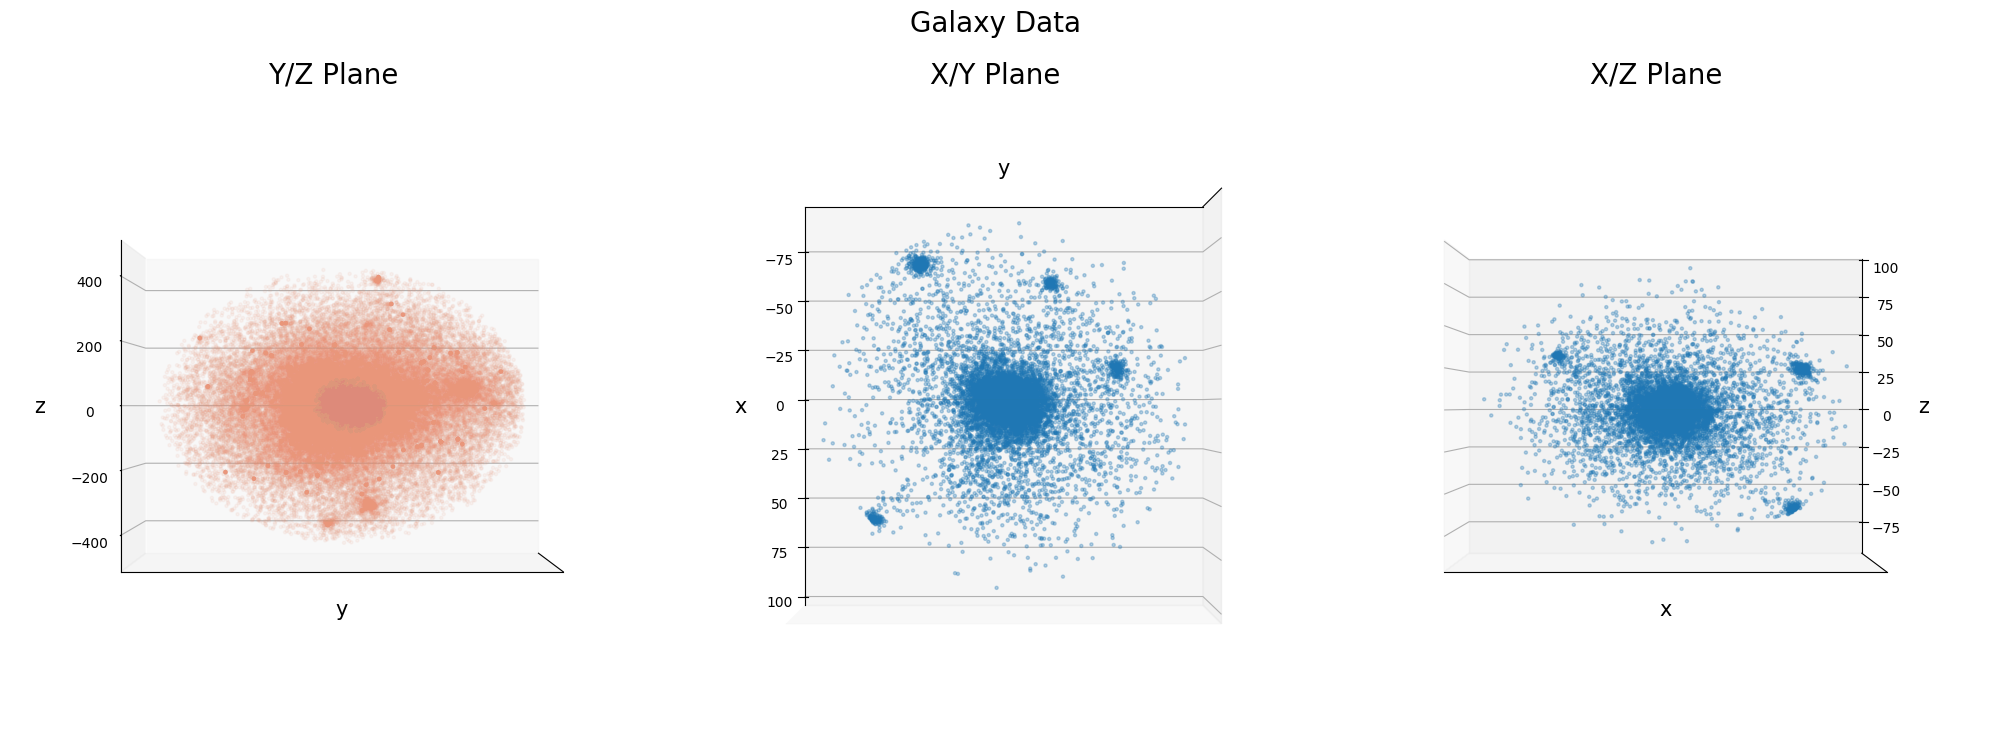

In [31]:
from dynamics import Plot_3d_scatter_with_dm
from dynamics import Plot_3d_scatter

Plot_3d_scatter_with_dm(xdata, ydata, zdata, dm_xdata, dm_ydata, dm_zdata, 'x', 'y', 'z', 'Galaxy Data')




In [32]:
#Sort the data by distance from the centre of the galaxy
#Create an array called mapping which has the final after its sorted in terms of distance, therefore any other data can be sorted in the same way

from dynamics import create_mapping
mapping = create_mapping(rdata)


#The array mapping contains the indicies of the rdata array which are sorted in ascending distance from the centre of the galaxy (rdata[mapping[0]] is the minimum distance)



massdata_sorted = np.array(massdata[mapping])
rdata_sorted = np.array(rdata[mapping])

In [33]:
#Calculate total angular momentum of all particles in the simulation

#Angular momentum of one particle is L = r x p
#Or if we remove the mass from p we get L = m * (r x v)
#Then we want to sum up all the L vectors for all particles to get the resulting L of the galaxy

#points = np.column_stack((xdata, ydata, zdata)) (each particles r vector) (sorted by r)
#rdata = np.sqrt(xdata**2 + ydata**2 + zdata**2) (each particles r magnitude)

#Moving into 3d we need to sort the position vectors in terms of their overall distance from the centre of the galaxy

velocities_sorted = np.array(velocities[mapping])
points_sorted = np.array(points[mapping])

momentum_sorted = velocities_sorted * massdata_sorted[:, np.newaxis] * Msun

angular_momentum = np.cross(points_sorted, momentum_sorted)

total_angular_momentum = np.sum(angular_momentum, axis=0)



In [34]:
total_angular_momentum_unitv = total_angular_momentum/np.linalg.norm(total_angular_momentum)



In [35]:
#Now need to rotate axes so that the angular momentum vector is pointing along the Z direction
#This will make the galaxy be a disc in the xy plane and with anti clockwise rotation

def matrix_of_rotation(v1, v2):

    
    cos = np.dot(v1, v2)
    cross = np.cross(v1, v2)
    sin = np.sum(cross**2)**0.5
    cross = cross/sin
    rotation_matrix = np.array([[cos + cross[0]**2*(1-cos), cross[0]*cross[1]*(1-cos) - cross[2]*sin, cross[0]*cross[2]*(1-cos) + cross[1]*sin],
                                [cross[1]*cross[0]*(1-cos) + cross[2]*sin, cos + cross[1]**2*(1-cos), cross[1]*cross[2]*(1-cos) - cross[0]*sin],
                                [cross[2]*cross[0]*(1-cos) - cross[1]*sin, cross[2]*cross[1]*(1-cos) + cross[0]*sin, cos + cross[2]**2*(1-cos)]])
    #Rotation matrix found from wikipedia
    return rotation_matrix

In [36]:
rotation_matrix = matrix_of_rotation(total_angular_momentum_unitv, np.array([0, 0, 1]))

rotated_tot_ang_mom = np.dot(rotation_matrix, total_angular_momentum)


rotated_tot_ang_mom_unitv = rotated_tot_ang_mom/np.linalg.norm(rotated_tot_ang_mom)


In [37]:
#Now apply the rotation matrix to the velocity vectors

velocities_rotated = np.dot(rotation_matrix, velocities_sorted[:][:].T).T
rotated_points = np.dot(rotation_matrix, points_sorted[:][:].T).T


In [38]:
#Now we want to change the velocities from cartesian to cylindrical coordinates
#If r = sqrt(x^2 + y^2) then vr = (x(xdot) + y(ydot))/r
#If tan(theta) = y/x then vtheta = ((ydot)x - y(xdot))/r^2

def cartesian_to_cylindrical_velocity(vx, vy, vz, x, y):
    vr = (x*vx + y*vy)/(x**2 + y**2)**0.5
    vtheta = (x*vy - y*vx)/(x**2 + y**2)**0.5
    vz = vz
    return np.array([vr, vtheta, vz]).T


cylindrical_velocities = cartesian_to_cylindrical_velocity(velocities_rotated[:,0], velocities_rotated[:,1], velocities_rotated[:,2], rotated_points[:,0], rotated_points[:,1])



KeyboardInterrupt: 

In [ ]:
#Now need to convert the points from cartesian to cylindrical coordinates

def cartesian_to_cylindrical_points(x, y, z):
    r = (x**2 + y**2)**0.5
    theta = np.arctan2(y, x)
    z = z
    return np.array([r, theta, z]).T

cylindrical_points = cartesian_to_cylindrical_points(rotated_points[:,0], rotated_points[:,1], rotated_points[:,2])

In [ ]:
#Now we want to calculate the rotation curve of the galaxy
#We want to plot the vr, vtheta and vz against r for the particles
#Create different bins of r and calculate the average vr, vtheta and vz for each bin

from dynamics import bins_calc

variables = defaultdict(list)
variables['vr'] = cylindrical_velocities[:, 0]
variables['vtheta'] = cylindrical_velocities[:, 1]
variables['vz'] = cylindrical_velocities[:, 2]
variables['modv'] = np.sqrt(cylindrical_velocities[:, 0]**2 + cylindrical_velocities[:, 1]**2 + cylindrical_velocities[:, 2]**2)

cylindrical_shells = cylindrical_points[:,0] #r points


mean_r, mean_variables, upper_variables, lower_variables = bins_calc(variables, cylindrical_shells, number_of_bins=1000)


##Calculating the mean of the speeds in the bin of radius r

##We also want to calulate the 68% confidence interval of the speeds in the bin of radius r
##np.quantile(vtheta_list, (1-0.68)/2) i.e. (np.quantile(vtheta_list,0.16)) gives the lower bound,
##and np.quantile(vtheta_list, 0.84) givesthe upper bound

#Finding interval which captures 68% of speeds in the bin (1 standard deviation)

x = ~np.isnan(mean_variables['vr'])
mean_r = np.array(mean_r)[x]
for k in mean_variables:
    mean_variables[k] = np.array(mean_variables[k])[x]
    upper_variables[k] = np.array(upper_variables[k])[x]
    lower_variables[k] = np.array(lower_variables[k])[x]

/mnt/users/darnej/miniconda3/envs/ozyenv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/mnt/users/darnej/miniconda3/envs/ozyenv/lib/python3.11/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


IndexError: index 0 is out of bounds for axis 0 with size 0

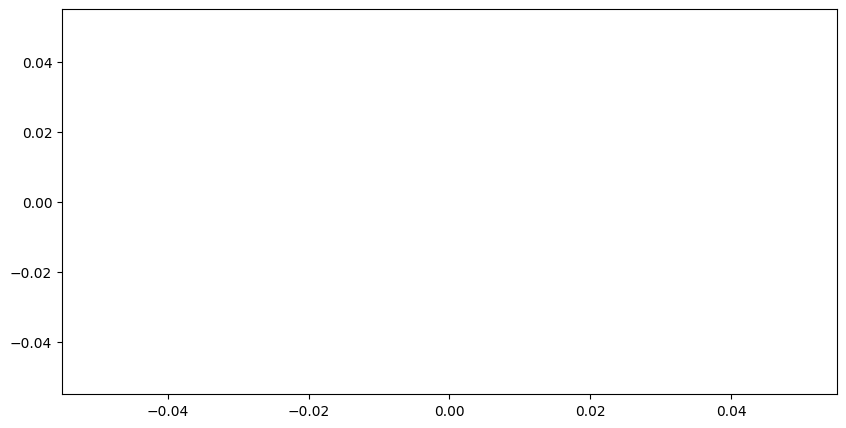

In [ ]:
fig, ax = plt.subplots(figsize =(10, 5))

plt.plot(mean_r, mean_variables['vtheta']*kpc_to_m, '.')
gfg = make_interp_spline(mean_r, mean_variables['vtheta']*kpc_to_m, k=3) 

y_new = gfg(mean_r) 

plt.plot(mean_r, y_new)
plt.xlabel('R (Kpc)')
plt.ylabel('Azimuthal Velocity (m/s)')
plt.title('Galaxy Rotation Curve', size=15)

plt.show()

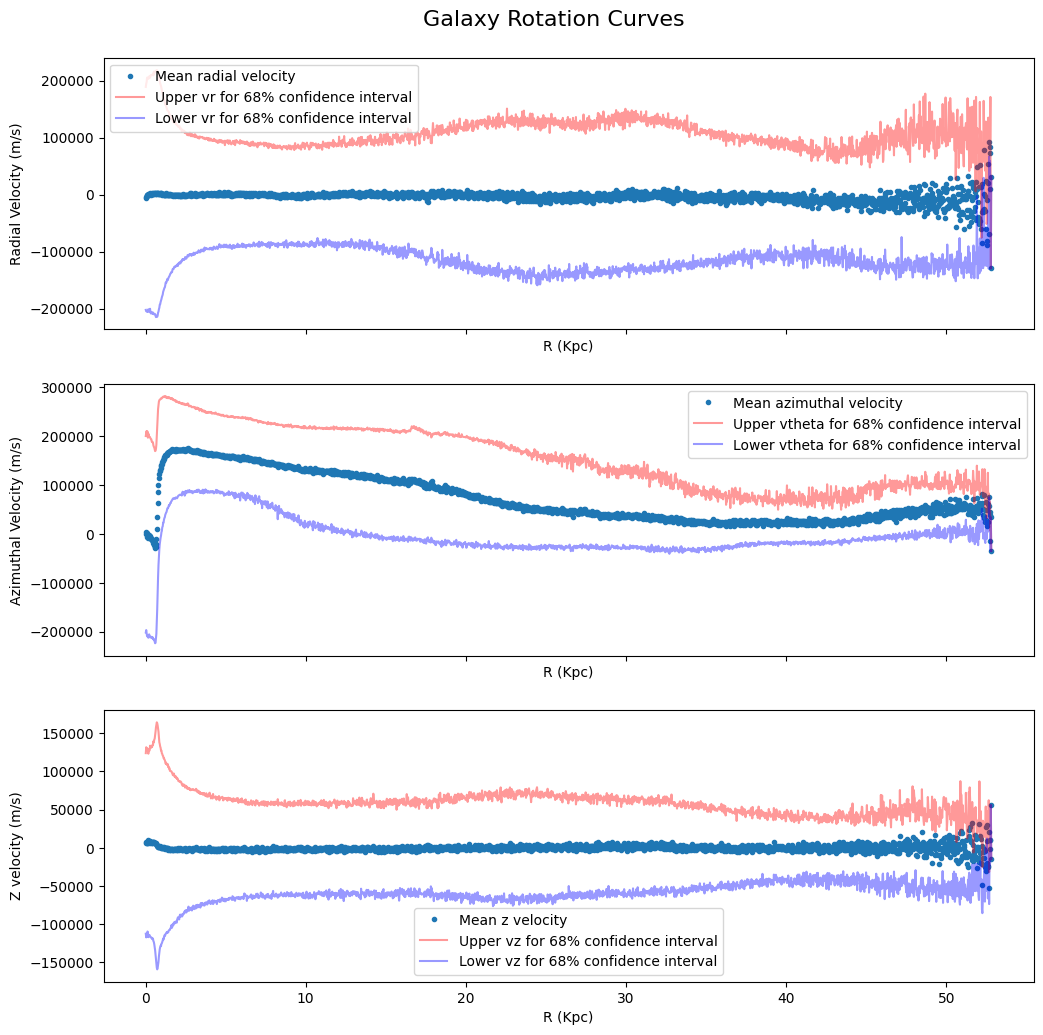

In [ ]:
figure, axis = plt.subplots(3, sharex=True, figsize=(12, 12))
figure.suptitle('Galaxy Rotation Curves', fontsize=16, y = 0.92)



axis[0].plot(mean_r, mean_variables['vr']*kpc_to_m, '.', label = 'Mean radial velocity')
axis[0].set_xlabel('R (Kpc)')
axis[0].set_ylabel('Radial Velocity (m/s)')
axis[0].plot(mean_r, upper_variables['vr']*kpc_to_m, 'r', label = 'Upper vr for 68% confidence interval', alpha = 0.4)
axis[0].plot(mean_r, lower_variables['vr']*kpc_to_m, 'b', label = 'Lower vr for 68% confidence interval', alpha = 0.4)
axis[0].legend()


axis[1].plot(mean_r, mean_variables['vtheta']*kpc_to_m, '.', label = 'Mean azimuthal velocity')
axis[1].set_xlabel('R (Kpc)')
axis[1].set_ylabel('Azimuthal Velocity (m/s)')
axis[1].plot(mean_r, upper_variables['vtheta']*kpc_to_m, 'r', label = 'Upper vtheta for 68% confidence interval', alpha = 0.4)
axis[1].plot(mean_r, lower_variables['vtheta']*kpc_to_m, 'b', label = 'Lower vtheta for 68% confidence interval', alpha = 0.4)
axis[1].legend()


axis[2].plot(mean_r, mean_variables['vz']*kpc_to_m, '.', label = 'Mean z velocity')
axis[2].set_xlabel('R (Kpc)')
axis[2].set_ylabel('Z velocity (m/s)')
axis[2].plot(mean_r, upper_variables['vz']*kpc_to_m, 'r', label = 'Upper vz for 68% confidence interval', alpha = 0.4)
axis[2].plot(mean_r, lower_variables['vz']*kpc_to_m, 'b', label = 'Lower vz for 68% confidence interval', alpha = 0.4)
axis[2].legend()

plt.show()


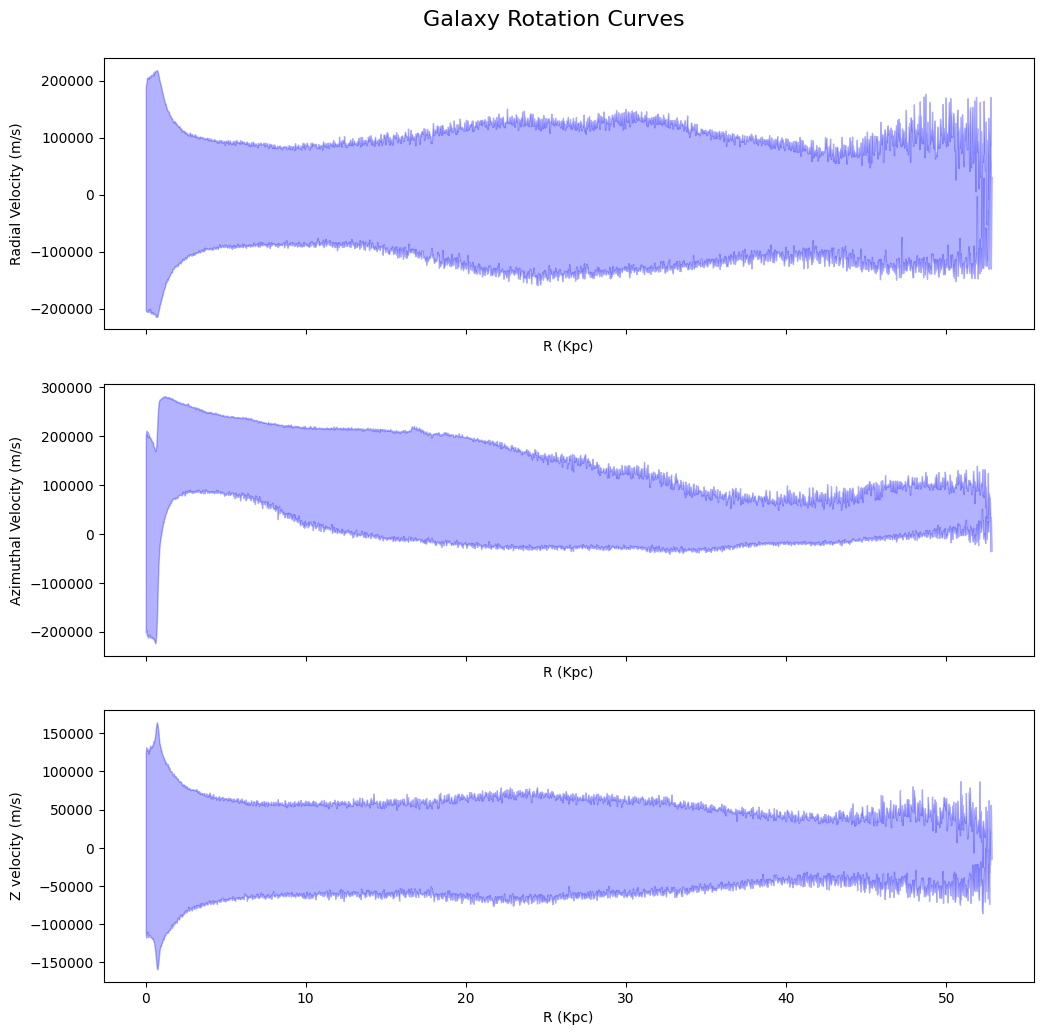

In [ ]:
figure, axis = plt.subplots(3, sharex=True, figsize=(12, 12))
figure.suptitle('Galaxy Rotation Curves', fontsize=16, y = 0.92)

axis[0].set_xlabel('R (Kpc)')
axis[0].set_ylabel('Radial Velocity (m/s)')
axis[0].fill_between(mean_r, lower_variables['vr']*kpc_to_m, upper_variables['vr']*kpc_to_m, color='blue', alpha=0.3)


axis[1].set_xlabel('R (Kpc)')
axis[1].set_ylabel('Azimuthal Velocity (m/s)')
axis[1].fill_between(mean_r, lower_variables['vtheta']*kpc_to_m, upper_variables['vtheta']*kpc_to_m, color='blue', alpha=0.3)


axis[2].set_xlabel('R (Kpc)')
axis[2].set_ylabel('Z velocity (m/s)')
axis[2].fill_between(mean_r, lower_variables['vz']*kpc_to_m, upper_variables['vz']*kpc_to_m, color='blue', alpha=0.3)



plt.show()

In [ ]:
#Now we want to calculate acceleration of particles as a function of radius 
#Acceleration is given by a = v^2/r
#We want to calculate the acceleration in the radial direction for each particle and then average it for each bin

#Already have mean r array

number_of_bins = 1000

max_r = max(cylindrical_shells)
min_r = min(cylindrical_shells)
length_of_bins = (max_r - min_r)/number_of_bins

mean_acc_obs = []

for i in range(number_of_bins):
    max_r_for_bin = min_r + (i+1)*length_of_bins
    min_r_for_bin = min_r + i*length_of_bins

    mask = (cylindrical_shells > min_r_for_bin) & (cylindrical_shells < max_r_for_bin)

    vtheta_in_bin = cylindrical_velocities[:,1][mask]

    mean_a_in_bin = np.mean(vtheta_in_bin**2/(cylindrical_shells[mask]))

    mean_acc_obs.append(mean_a_in_bin)

mean_acc_obs = np.array(mean_acc_obs)
mean_acc_obs = mean_acc_obs[x]*kpc_to_m


In [ ]:
#We found acceleration that is observed by the rotational velocity using a = v_theta^2/r
#Now we want to calculate the acceleration that is observed by the mass distribution using a = GM/r^2
#We want to compare the two accelerations

mean_acc_bar = []

for i in mean_r:
    r_in_m = i*kpc_to_m
    mask = rdata_sorted < i
    inside_mass = np.sum(massdata_sorted[mask]*Msun)
    mean_acc_bar.append(constants.G*inside_mass/(r_in_m**2))


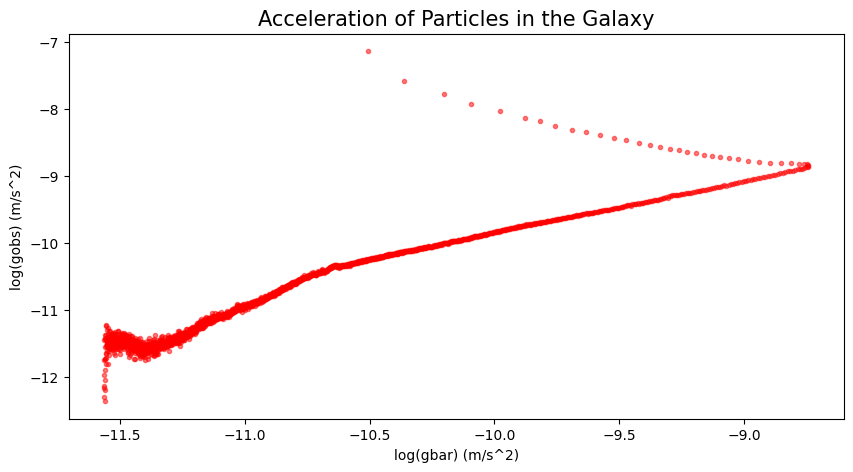

In [ ]:
fig, ax = plt.subplots(figsize =(10, 5))

plt.xlabel('log(gbar) (m/s^2)')
plt.ylabel('log(gobs) (m/s^2)')
plt.title('Acceleration of Particles in the Galaxy', size=15)
plt.plot(np.log10(mean_acc_bar), np.log10(mean_acc_obs), '.', color = 'r', alpha = 0.5)

plt.show()
